
# EXPT NO. 3 — Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Student Name:** Mohamed Aashik S  
**Roll No.:** 24BAD072  




# Task A: DATASET PREPARATION


## Step 1 — Install / Import Required Libraries

In [1]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Step 2 — Load the CIFAR-10 Dataset

In [2]:

# CIFAR-10 contains 60,000 colour images belonging to 10 classes.
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert labels from shape (n, 1) to (n,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", x_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2035s 12us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000,)


## Step 3 — Visualize Sample Images

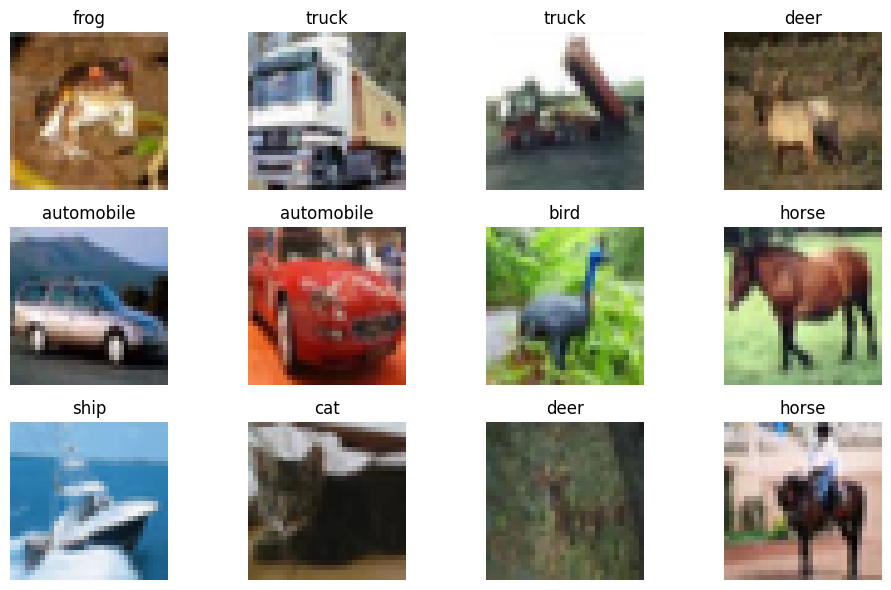

In [3]:

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 4 — Preprocess and Split the Dataset

In [4]:

# Normalize pixel values from [0, 255] to [0, 1].
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use 5,000 images from the training set for validation.
validation_size = 5000

x_val = x_train_full[-validation_size:]
y_val = y_train_full[-validation_size:]

x_train = x_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Testing set:", x_test.shape, y_test.shape)


Training set: (45000, 32, 32, 3) (45000,)
Validation set: (5000, 32, 32, 3) (5000,)
Testing set: (10000, 32, 32, 3) (10000,)


## Step 5 — Convert Labels to Categorical Format

In [5]:

# Convert class labels into one-hot encoded vectors.
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print("Example original label:", y_train[0])
print("Example one-hot label:", y_train_cat[0])


Example original label: 6
Example one-hot label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


#  Task B: CNN MODEL IMPLEMENTATION

## Step 6 — Build the CNN Model

In [6]:

model = Sequential([
    # First convolution block
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    # Second convolution block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Third convolution block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Classification layers
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Compile the CNN

In [7]:

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


# Task C: MODEL TRAINING AND EVALUATION

## Step 8 — Train the CNN Model

In [8]:

# Train the model.
# 15 epochs provides a reasonable lab demonstration while keeping runtime manageable.
history = model.fit(
    x_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val_cat),
    verbose=1
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 82ms/step - accuracy: 0.3440 - loss: 1.7689 - val_accuracy: 0.4334 - val_loss: 1.5738
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.4847 - loss: 1.4221 - val_accuracy: 0.5392 - val_loss: 1.3085
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.5483 - loss: 1.2684 - val_accuracy: 0.5914 - val_loss: 1.1353
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.5897 - loss: 1.1603 - val_accuracy: 0.6044 - val_loss: 1.0931
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.6205 - loss: 1.0781 - val_accuracy: 0.6250 - val_loss: 1.0500
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.6460 - loss: 1.0052 - val_accuracy: 0.6848 - val_loss: 0.9043
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.6669 - loss: 0.9511 - val_accuracy: 0.6898 - val_loss: 0.8850
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6871 - loss: 0.8968 - 

## Step 9 — Record Training and Validation Performance

In [9]:

# Get the final recorded values.
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print(f"Final Training Accuracy   : {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy : {final_val_accuracy:.4f}")
print(f"Final Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")


Final Training Accuracy   : 0.7660
Final Validation Accuracy : 0.7150
Final Training Loss       : 0.6688
Final Validation Loss     : 0.8236


## Step 10 — Evaluate the Model on the Test Set

In [10]:

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print(f"Testing Loss    : {test_loss:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Testing Loss    : 0.8636
Testing Accuracy: 0.7049


## Step 11 — Plot Accuracy vs Epoch

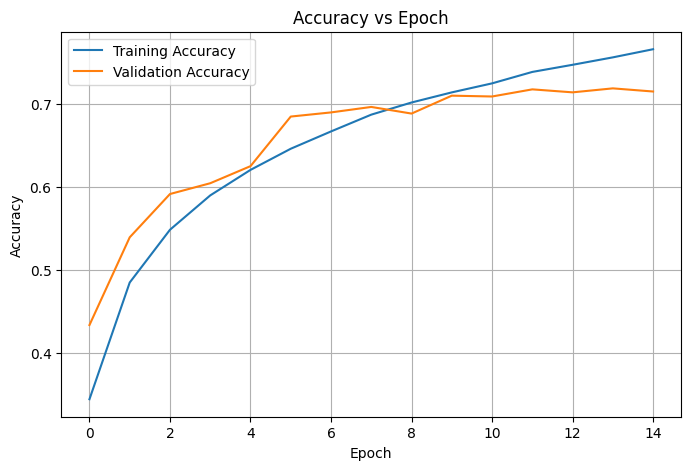

In [11]:

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Step 12 — Plot Loss vs Epoch

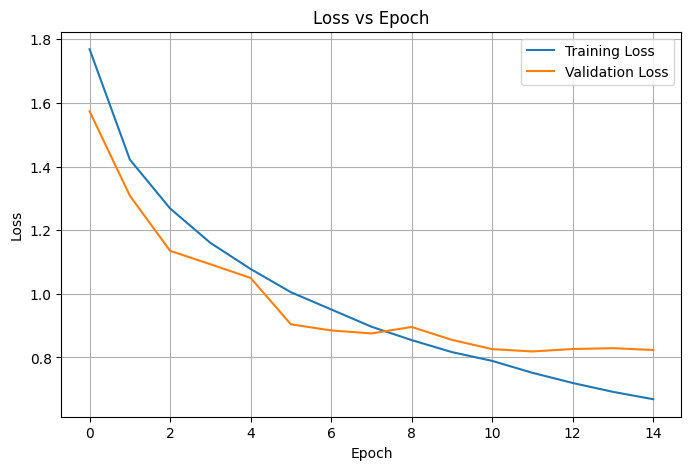

In [12]:

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Task D: PERFORMANCE ANALYSIS

## Step 13 — Generate Predictions

In [13]:

# Predict class probabilities for the test images.
pred_probabilities = model.predict(x_test, verbose=0)
y_pred = np.argmax(pred_probabilities, axis=1)

print("Predictions generated successfully.")
print("First 10 predicted classes:")
print([class_names[i] for i in y_pred[:10]])


Predictions generated successfully.
First 10 predicted classes:
['cat', 'ship', 'ship', 'ship', 'frog', 'frog', 'automobile', 'frog', 'cat', 'automobile']


## Step 14 — Confusion Matrix

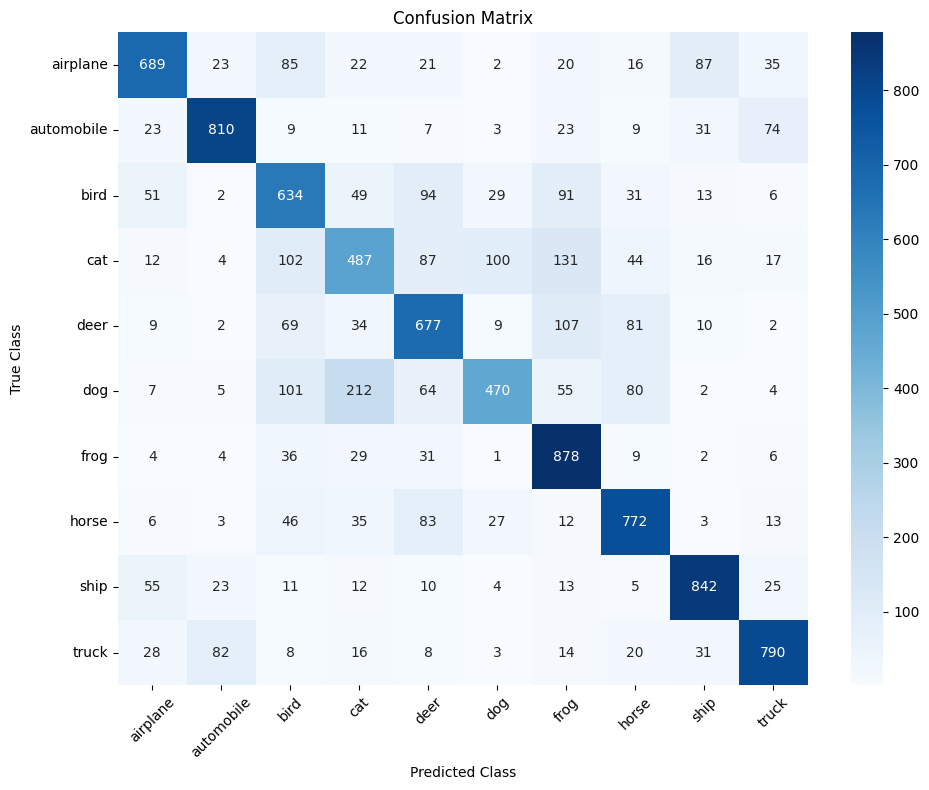

In [14]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 15 — Classification Report

In [15]:

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

    airplane     0.7794    0.6890    0.7314      1000
  automobile     0.8455    0.8100    0.8274      1000
        bird     0.5758    0.6340    0.6035      1000
         cat     0.5369    0.4870    0.5107      1000
        deer     0.6257    0.6770    0.6503      1000
         dog     0.7253    0.4700    0.5704      1000
        frog     0.6533    0.8780    0.7491      1000
       horse     0.7235    0.7720    0.7470      1000
        ship     0.8120    0.8420    0.8267      1000
       truck     0.8128    0.7900    0.8012      1000

    accuracy                         0.7049     10000
   macro avg     0.7090    0.7049    0.7018     10000
weighted avg     0.7090    0.7049    0.7018     10000



## Step 16 — Display Sample Predictions

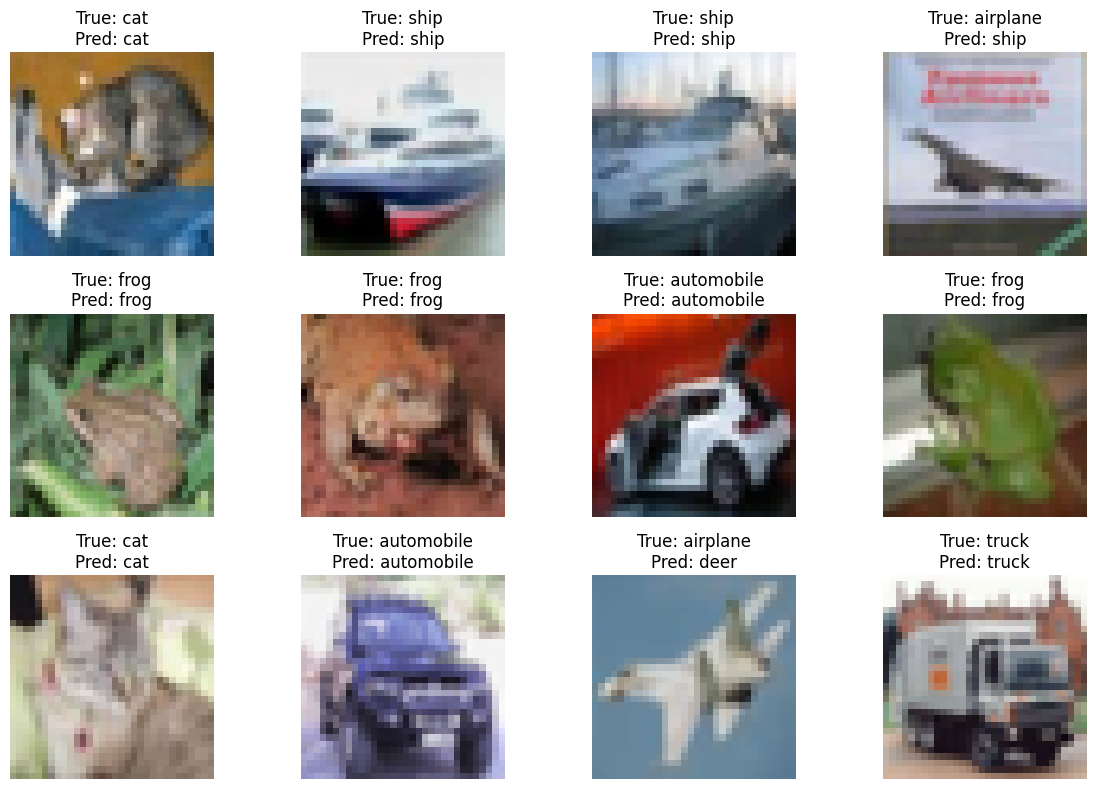

In [16]:

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    true_label = class_names[y_test[i]]
    predicted_label = class_names[y_pred[i]]

    title = f"True: {true_label}\nPred: {predicted_label}"
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 17 — Display Misclassified Images

Number of misclassified images: 2951


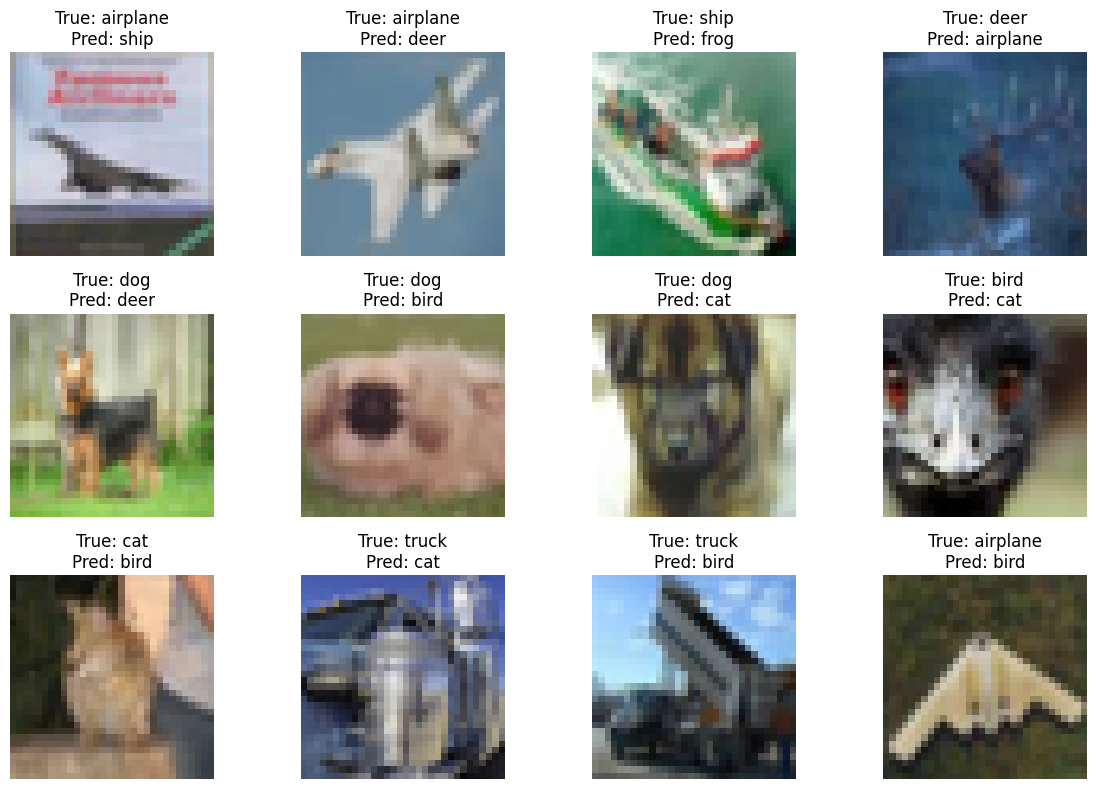

In [17]:

# Find images where prediction does not match the true class.
misclassified_indices = np.where(y_pred != y_test)[0]

print("Number of misclassified images:", len(misclassified_indices))

plt.figure(figsize=(12, 8))

num_to_show = min(12, len(misclassified_indices))

for i in range(num_to_show):
    idx = misclassified_indices[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 18 — Automatically Generate a Performance Summary

In [18]:

print("=" * 55)
print("CNN PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Training Accuracy   : {final_train_accuracy:.2%}")
print(f"Validation Accuracy : {final_val_accuracy:.2%}")
print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")
print(f"Testing Accuracy    : {test_accuracy:.2%}")
print(f"Testing Loss        : {test_loss:.4f}")
print(f"Misclassified       : {len(misclassified_indices)} / {len(y_test)}")
print("=" * 55)


CNN PERFORMANCE SUMMARY
Training Accuracy   : 76.60%
Validation Accuracy : 71.50%
Training Loss       : 0.6688
Validation Loss     : 0.8236
Testing Accuracy    : 70.49%
Testing Loss        : 0.8636
Misclassified       : 2951 / 10000
